# CSC5035Z A2 — Results Analysis
**Student:** Praise Jaravani (JRVPRA001) and Mathew Maartens (MRTMAT016) | **Language:** Yoruba (`yor`)

Loads saved results from `results/` and produces the tables and figures used in the report.
No training occurs here — all outputs come from pre-saved JSON files.

**Run this notebook after completing all steps in `run.ipynb`.**

| Section | What it produces |
|---|---|
| 1 | Load all result files |
| 2 | Main results table (baseline vs Extension B) |
| 3 | Tokenizer fertility comparison table |
| 4 | Bar chart: F1 scores baseline vs Extension B |
| 5 | Fertility distribution line chart |
| 6 | MasakhaNews confusion matrix (baseline) |
| 7 | NER per-entity F1 bar chart |
| 8 | Qualitative tokenizer probe table (10 diacritic words) |
| 9 | Error analysis: news disagreements + NER error patterns |

In [1]:
# Mount Drive and navigate to project root (Colab only)
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_PATH = '/content/drive/MyDrive/csc5035z-a2'
    os.chdir(PROJECT_PATH)
    if PROJECT_PATH not in sys.path:
        sys.path.insert(0, PROJECT_PATH)
except ImportError:
    pass  # running locally — assume cwd is already project root

print('Working directory:', os.getcwd())

Working directory: /home/mathew/Documents/Natural Language Processing/Assignment_2_group/African-Language-FineTuning/notebooks


In [2]:
import os, sys, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Make sure we can import project modules
project_root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Work from project root so relative paths resolve correctly
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Working directory:', os.getcwd())

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

Working directory: /home/mathew/Documents/Natural Language Processing/Assignment_2_group/African-Language-FineTuning


---
## Section 1 — Load all results

Reads every `.json` file from the `results/` directory into a single dictionary. All subsequent sections draw from this dictionary — no file I/O after this point.

Expected files: `news_baseline`, `ner_baseline`, `news_extb`, `ner_extb`, `eval_*` variants, `tokenizer_analysis_baseline`, `tokenizer_analysis_extb`, `lr_sweep`.

In [3]:
results = {}
for f in sorted(glob.glob('results/*.json')):
    name = os.path.basename(f).replace('.json', '')
    with open(f, encoding='utf-8') as fp:
        results[name] = json.load(fp)

print(f'Loaded {len(results)} result files:')
for k in results:
    print(f'  {k}')

Loaded 16 result files:
  eval_ner_ner_baseline
  eval_ner_ner_extb
  eval_news_news_baseline
  eval_news_news_extb
  lr_sweep
  ner_baseline
  ner_extb
  news_baseline
  news_extb
  peft_ia3_default
  peft_lora_r16
  peft_lora_r8
  peft_prompt_v10
  peft_prompt_v20
  tokenizer_analysis_baseline
  tokenizer_analysis_extb


---
## Section 2 — Main results table

Compares baseline and Extension B test performance on both tasks. F1 scores are read from the `eval_*` files (written by `evaluate.py`) rather than the training files to avoid any Drive sync artefacts.

**Expected results (LR = 5e-5):**
| Model | News Macro-F1 | NER Span-F1 |
|---|---|---|
| Baseline | 0.8641 | 0.8407 |
| Extension B | 0.8605 | 0.8393 |
| Delta | −0.0036 | −0.0014 |

In [4]:
def safe_get(d, *keys, default=None):
    for k in keys:
        if k in d:
            return d[k]
    return default

# Use eval_* files as authoritative source for test F1
# (written by evaluate.py after training, avoids Drive sync race conditions)
rows = []
for run, eval_key, label in [
    ('news_baseline', 'eval_news_news_baseline', 'Baseline'),
    ('news_extb',     'eval_news_news_extb',     'Extension B'),
]:
    news_f1 = safe_get(results.get(eval_key, {}), 'test_macro_f1')
    rows.append({'Run': label, 'MasakhaNews Macro-F1': news_f1})

for i, (run, eval_key) in enumerate([
    ('ner_baseline', 'eval_ner_ner_baseline'),
    ('ner_extb',     'eval_ner_ner_extb'),
]):
    ner_f1 = safe_get(results.get(eval_key, {}), 'test_span_f1')
    rows[i]['MasakhaNER Span-F1'] = ner_f1

df_main = pd.DataFrame(rows).set_index('Run')

# Delta row
delta = df_main.loc['Extension B'] - df_main.loc['Baseline']
delta.name = 'Delta'
df_main = pd.concat([df_main, delta.to_frame().T])

print('\nMain Results Table')
print('=' * 55)
print(df_main.to_string(float_format='{:.4f}'.format))


Main Results Table
             MasakhaNews Macro-F1  MasakhaNER Span-F1
Baseline                   0.8641              0.8407
Extension B                0.8605              0.8393
Delta                     -0.0036             -0.0014


---
## Section 3 — Tokenizer fertility table

Compares token-per-word statistics between the original mmBERT-small tokenizer and the Yoruba-extended version. Fertility is measured on the combined MasakhaNews + MasakhaNER training corpus (~198k words).

The key metric is `% single-token`: the fraction of words tokenised as a single unit. A high value means the vocabulary covers the target language well.

In [5]:
fert_rows = []
for key, label in [('tokenizer_analysis_baseline', 'mmBERT-small (original)'),
                    ('tokenizer_analysis_extb',     'mmBERT-small + Yoruba')]:
    r = results.get(key, {})
    fert_rows.append({
        'Tokenizer':         label,
        'Vocab size':        r.get('vocab_size', 'N/A'),
        'Mean toks/word':    r.get('mean_tokens_per_word', 'N/A'),
        'Median':            r.get('median_tokens_per_word', 'N/A'),
        '95th pct':          r.get('pct95_tokens_per_word', 'N/A'),
        '% single-token':    r.get('distribution', {}).get('1_token', 'N/A'),
    })

df_fert = pd.DataFrame(fert_rows).set_index('Tokenizer')
print('\nTokenizer Fertility Table')
print('=' * 70)
print(df_fert.to_string())


Tokenizer Fertility Table
                         Vocab size  Mean toks/word  Median  95th pct  % single-token
Tokenizer                                                                            
mmBERT-small (original)      256000        3.119662     3.0       7.0          0.2431
mmBERT-small + Yoruba        256000        1.655644     1.0       4.0          0.6608


---
## Section 4 — Bar chart: Baseline vs Extension B

Visual comparison of test F1 for both models on both tasks. Saved to `results/fig_main_results.png` for use in the report.

The near-equal bar heights confirm that vocabulary adaptation has negligible downstream effect at the optimal learning rate.

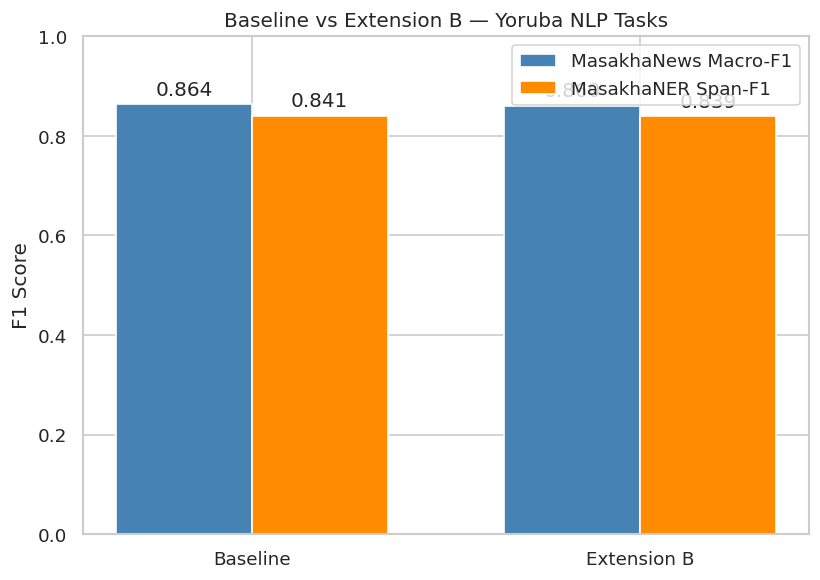

Saved -> results/fig_main_results.png


In [6]:
runs   = ['Baseline', 'Extension B']
news_f = [safe_get(results.get(k, {}), 'test_macro_f1', default=0)
          for k in ['eval_news_news_baseline', 'eval_news_news_extb']]
ner_f  = [safe_get(results.get(k, {}), 'test_span_f1', default=0)
          for k in ['eval_ner_ner_baseline', 'eval_ner_ner_extb']]

x      = np.arange(len(runs))
width  = 0.35
fig, ax = plt.subplots(figsize=(7, 5))

bars1 = ax.bar(x - width/2, news_f, width, label='MasakhaNews Macro-F1', color='steelblue')
bars2 = ax.bar(x + width/2, ner_f,  width, label='MasakhaNER Span-F1',   color='darkorange')

ax.set_ylabel('F1 Score')
ax.set_title('Baseline vs Extension B — Yoruba NLP Tasks')
ax.set_xticks(x)
ax.set_xticklabels(runs)
ax.set_ylim(0, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.savefig('results/fig_main_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/fig_main_results.png')

---
## Section 5 — Fertility distribution chart

Line chart showing the proportion of words at each token-per-word count (1, 2, 3, 4+) for both tokenizers. Saved to `results/fig_fertility.png`.

The dramatic shift of the extended tokenizer toward the 1-token bucket illustrates the fertility improvement from vocabulary adaptation.

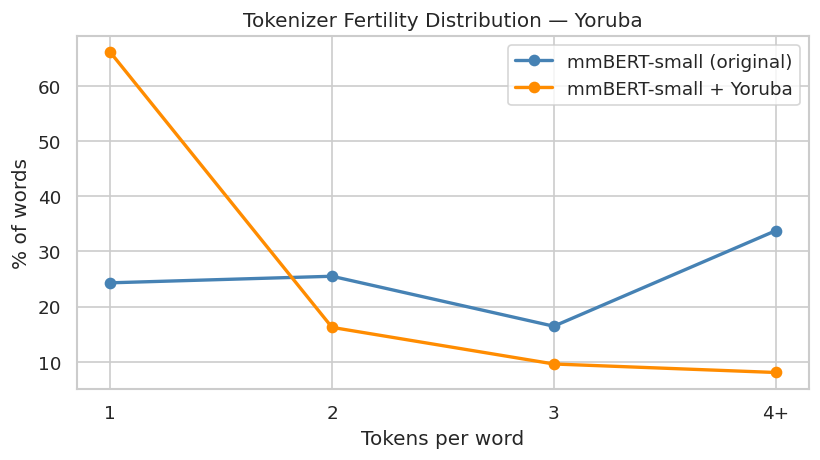

Saved → results/fig_fertility.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

for key, label, color in [
    ('tokenizer_analysis_baseline', 'mmBERT-small (original)', 'steelblue'),
    ('tokenizer_analysis_extb',     'mmBERT-small + Yoruba',   'darkorange'),
]:
    r = results.get(key)
    if r is None:
        print(f'Missing: {key}')
        continue
    dist = r.get('distribution', {})
    buckets = ['1_token', '2_tokens', '3_tokens', '4+_tokens']
    labels  = ['1', '2', '3', '4+']
    values  = [dist.get(b, 0) * 100 for b in buckets]
    ax.plot(labels, values, marker='o', label=label, color=color, linewidth=2)

ax.set_xlabel('Tokens per word')
ax.set_ylabel('% of words')
ax.set_title('Tokenizer Fertility Distribution — Yoruba')
ax.legend()
fig.tight_layout()
plt.savefig('results/fig_fertility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/fig_fertility.png')

---
## Section 6 — MasakhaNews confusion matrix (baseline)

Heatmap of predicted vs true labels for all 411 test examples using the baseline model. Saved to `results/fig_news_confusion.png`.

The dominant off-diagonal pattern (entertainment/religion confusion) motivates the error analysis discussion in the report.

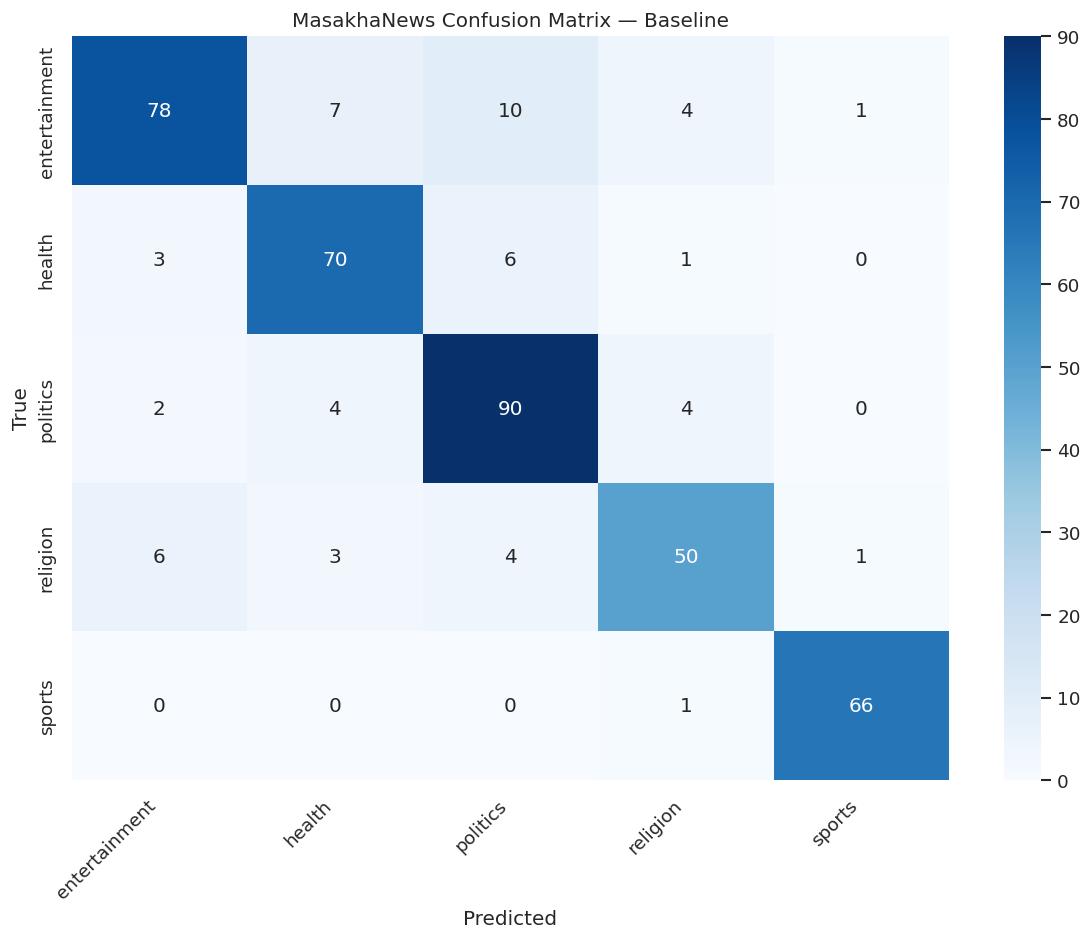

Saved → results/fig_news_confusion.png


In [8]:
from sklearn.metrics import confusion_matrix

r = results.get('news_baseline', {})
preds  = r.get('test_predictions')
labels = r.get('test_true_labels')
names  = r.get('label_names')

if preds is None or labels is None:
    print('Predictions not found in news_baseline.json. Re-running evaluate.py to generate them.')
else:
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=names, yticklabels=names, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('MasakhaNews Confusion Matrix — Baseline')
    plt.xticks(rotation=45, ha='right')
    fig.tight_layout()
    plt.savefig('results/fig_news_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → results/fig_news_confusion.png')

---
## Section 7 — NER per-entity F1: Baseline vs Extension B

Grouped bar chart showing span-F1 for each of the four entity types (PER, ORG, LOC, DATE) for baseline and Extension B. Saved to `results/fig_ner_entities.png`.

DATE is consistently the hardest entity; PER is easiest. The minimal difference between baseline and Ext B across all entity types confirms the near-parity finding.

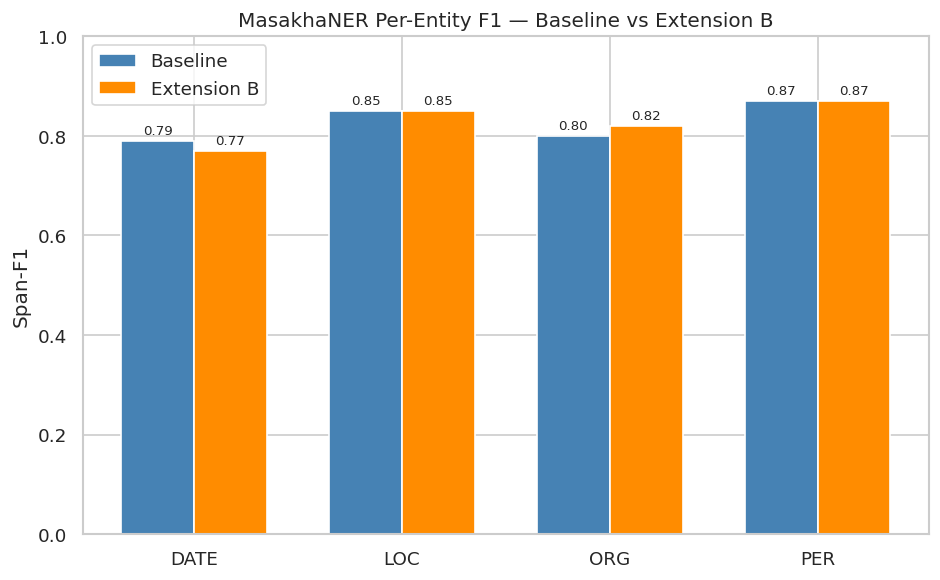

Saved → results/fig_ner_entities.png


In [9]:
baseline_per = results.get('ner_baseline', {}).get('per_entity_f1', {})
extb_per     = results.get('ner_extb',     {}).get('per_entity_f1', {})

if not baseline_per:
    print('per_entity_f1 not found in ner_baseline.json')
else:
    entities = sorted(set(baseline_per) | set(extb_per))
    base_vals = [baseline_per.get(e, 0) for e in entities]
    extb_vals = [extb_per.get(e, 0)     for e in entities]

    x      = np.arange(len(entities))
    width  = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, base_vals, width, label='Baseline',    color='steelblue')
    bars2 = ax.bar(x + width/2, extb_vals, width, label='Extension B', color='darkorange')

    ax.set_ylabel('Span-F1')
    ax.set_title('MasakhaNER Per-Entity F1 — Baseline vs Extension B')
    ax.set_xticks(x)
    ax.set_xticklabels(entities)
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
    ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
    fig.tight_layout()
    plt.savefig('results/fig_ner_entities.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → results/fig_ner_entities.png')

---
## Section 8 — Qualitative tokenizer probe

Shows before/after tokenisation for 10 Yoruba words with complex diacritics. Illustrates the practical effect of vocabulary extension on individual words.

Words with stacked diacritics (e.g. *ẹ̀kọ́*, *ọjọ́*) that previously produced 5–6 tokens are now represented in 1–2 tokens, including some as single units.

In [10]:
base_r = results.get('tokenizer_analysis_baseline', {}).get('diacritic_words', {})
extb_r = results.get('tokenizer_analysis_extb',     {}).get('diacritic_words', {})

rows = []
for word in base_r:
    before = base_r[word]['tokens']
    after  = extb_r.get(word, {}).get('tokens', ['N/A'])
    rows.append({
        'Word':                  word,
        'Original tokenisation': ' | '.join(before),
        'Extended tokenisation': ' | '.join(after),
        'Tokens before':         len(before),
        'Tokens after':          len(after),
    })

if rows:
    df_tok = pd.DataFrame(rows)
    print('\nDiacritic Word Tokenisation')
    print(df_tok.to_string(index=False))
else:
    print('Run analyse_tokenizer.py (baseline + extb) to populate this section.')


Diacritic Word Tokenisation
   Word   Original tokenisation Extended tokenisation  Tokens before  Tokens after
    ọmọ              ▁ọ | m | ọ                   ọmọ              3             1
  ẹ̀kọ́   ▁ | ẹ | ̀ | k | ọ | ́              ẹ̀ | kọ́              6             2
 Àdùnní        ▁À | d | ùn | ní      ▁À | d | ùn | ní              4             4
    ìwé              ▁ì | w | é            ▁ì | w | é              3             3
  oúnjẹ         ▁o | ún | j | ẹ          ▁o | ún | jẹ              4             3
    ìlú              ▁ì | l | ú               ▁ì | lú              3             2
ẹ̀gbọ́n ▁ | ẹ | ̀ | gb | ọ | ́n            ẹ̀ | gbọ́n              6             2
  àárọ̀         ▁à | ár | ọ | ̀              àá | rọ̀              4             2
   ọjọ́          ▁ọ | j | ọ | ́                  ọjọ́              4             1
   ìgbà             ▁ì | gb | à              ▁ì | gbà              3             2


---
## Section 9 — Error analysis

Qualitative analysis of model errors to understand failure modes.

**News (cell below):** Identifies examples where baseline and Extension B disagree — cases fixed by Ext B reveal what vocabulary adaptation helped with; cases broken by Ext B reveal new confusion patterns introduced.

**NER (second cell):** Shows sentences where the baseline made errors on at least one entity, with token-level diff between predicted and true BIO sequences.

In [11]:
# -----------------------------------------------------------------------
# MasakhaNews: 5 examples baseline wrong, Extension B right — and vice versa
# -----------------------------------------------------------------------
from datasets import load_dataset
from config import NEWS_DATASET, LANGUAGE

base_news = results.get('news_baseline', {})
extb_news = results.get('news_extb',     {})

base_preds = base_news.get('test_predictions')
extb_preds = extb_news.get('test_predictions')
true_lbls  = base_news.get('test_true_labels')
label_names = base_news.get('label_names', [])

if base_preds and extb_preds and true_lbls:
    test_texts = load_dataset(NEWS_DATASET, LANGUAGE, split='test')['headline']

    base_wrong_extb_right = [
        i for i in range(len(true_lbls))
        if base_preds[i] != true_lbls[i] and extb_preds[i] == true_lbls[i]
    ]
    base_right_extb_wrong = [
        i for i in range(len(true_lbls))
        if base_preds[i] == true_lbls[i] and extb_preds[i] != true_lbls[i]
    ]

    print(f'Baseline wrong, ExtB right: {len(base_wrong_extb_right)} examples')
    print(f'Baseline right, ExtB wrong: {len(base_right_extb_wrong)} examples')

    print('\n--- Baseline WRONG, Extension B RIGHT (first 5) ---')
    for idx in base_wrong_extb_right[:5]:
        print(f'  [{idx}] Text: {test_texts[idx][:80]}')
        tl = label_names[true_lbls[idx]]  if label_names else true_lbls[idx]
        bp = label_names[base_preds[idx]] if label_names else base_preds[idx]
        ep = label_names[extb_preds[idx]] if label_names else extb_preds[idx]
        print(f'         True={tl}  Baseline={bp}  ExtB={ep}\n')

    print('\n--- Baseline RIGHT, Extension B WRONG (first 5) ---')
    for idx in base_right_extb_wrong[:5]:
        print(f'  [{idx}] Text: {test_texts[idx][:80]}')
        tl = label_names[true_lbls[idx]]  if label_names else true_lbls[idx]
        bp = label_names[base_preds[idx]] if label_names else base_preds[idx]
        ep = label_names[extb_preds[idx]] if label_names else extb_preds[idx]
        print(f'         True={tl}  Baseline={bp}  ExtB={ep}\n')
else:
    print('Predictions not yet available. Run training scripts first.')

Baseline wrong, ExtB right: 22 examples
Baseline right, ExtB wrong: 23 examples

--- Baseline WRONG, Extension B RIGHT (first 5) ---
  [2] Text: Òkò rùgùdù lórí Portable torí Small Doctor, àwọn ọdọ Agege kọjú oro si lóde ijó
         True=entertainment  Baseline=health  ExtB=entertainment

  [8] Text: Kwara Waka: Orin Wákà la fi ń ṣe Wáàsí, o tó ọdún 70 tí mo tí bẹ̀rẹ̀ láìnáání èé
         True=entertainment  Baseline=politics  ExtB=entertainment

  [21] Text: Damola Olatunji fojú balé ẹjọ́ lórí ẹ̀sùn pé ó dúnkookò mọ́ ọlọ́pàá àtàwọn ẹ̀sùn
         True=entertainment  Baseline=health  ExtB=entertainment

  [25] Text: Muyiwa Ademola: A ó jọ rọ́ọ̀kì ọdún 2021 papọ̀ ni lágbára Ọlọ́run
         True=entertainment  Baseline=sports  ExtB=entertainment

  [29] Text: Saheed Oṣupa on Nigeria's Politics: Mi ò ní ìyàwó nílé, àmọ́ bí mo ṣe ní ọmọrẹpẹ
         True=entertainment  Baseline=politics  ExtB=entertainment


--- Baseline RIGHT, Extension B WRONG (first 5) ---
  [61] Text: Charles Olumo A

In [12]:
# -----------------------------------------------------------------------
# NER: 5 baseline sentences with entity prediction errors
# (uses saved tag sequences only — no dataset reload needed)
# -----------------------------------------------------------------------
base_ner  = results.get('ner_baseline', {})
pred_tags = base_ner.get('test_pred_tags')
true_tags = base_ner.get('test_true_tags')

if pred_tags and true_tags:
    error_idxs = [
        i for i, (p_seq, t_seq) in enumerate(zip(pred_tags, true_tags))
        if p_seq != t_seq and any(t != 'O' for t in t_seq)
    ]

    print(f'NER sentences with errors: {len(error_idxs)} / {len(true_tags)}')
    print('\n--- 5 NER Error Sentences (baseline) ---')
    for idx in error_idxs[:5]:
        p_seq = pred_tags[idx]
        t_seq = true_tags[idx]
        diffs = [(j, t_seq[j], p_seq[j]) for j in range(len(t_seq)) if p_seq[j] != t_seq[j]]
        print(f'\n  [{idx}] True:  {t_seq}')
        print(f'        Pred:  {p_seq}')
        for pos, true_t, pred_t in diffs:
            print(f'        ERROR pos {pos}: true={true_t}  pred={pred_t}')
else:
    print('NER predictions not yet available. Run train_ner.py first.')

NER sentences with errors: 287 / 1964

--- 5 NER Error Sentences (baseline) ---

  [1] True:  ['O', 'B-PER', 'I-PER', 'I-PER', 'O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
        Pred:  ['O', 'B-PER', 'I-PER', 'I-PER', 'O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
        ERROR pos 7: true=I-ORG  pred=O
        ERROR pos 8: true=I-ORG  pred=O
        ERROR pos 9: true=I-ORG  pred=O
        ERROR pos 10: true=I-ORG  pred=O
        ERROR pos 11: true=I-ORG  pred=B-LOC

  [9] True:  ['O', 'O', 'O', 'B-DATE', 'I-DATE', 'I-DATE', 'O', 'B-DATE', 'I-DATE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-DATE', 'I-DATE', 'O', 'O', 'O', 'B-LOC']
        Pre